# 프로젝트 1 : 손수 설계하는 선형회귀, 당뇨병 수치를 맞춰보자!

첫 번째 프로젝트에서는 오늘 많은 시간을 들여서 직접 실습해 보았던  
**모델 설계 → 손실함수 정의 → 기울기 계산 → 경사하강법 학습** 을 직접 구현해봅니다.

데이터는 `sklearn.datasets` 의 **당뇨병(diabetes) 데이터셋** 을 사용합니다.  
환자 442명의 의료 데이터로 1년 후 당뇨 진행 수치를 예측하는 다중 선형 회귀 문제입니다.


**진행 순서**
1. 데이터 가져오기
2. X, y 데이터 numpy array 변환
3. train / test 분리
4. 모델 및 손실함수 정의
5. gradient 함수 구현
6. 학습률 설정 및 모델 학습
7. 성능 확인
8. 다양한 시각화 분석


## (1) 데이터 가져오기

`sklearn.datasets` 의 `load_diabetes()` 로 당뇨병 데이터셋 불러오기  
- `data.data` : 입력 feature (442명 × 10개 특성)
- `data.target` : 정답값 — 1년 후 당뇨 진행 수치 (숫자 클수록 악화)
- **feature 10개**: age, sex, bmi, bp, s1~s6 (혈액 수치들)
- 이미 **표준화(standardization)** 가 적용된 상태로 제공됨 → 별도 스케일링 불필요


In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd

# sklearn 내장 당뇨병 데이터셋 불러오기
# 환자 442명 데이터, feature 10개, target = 1년 후 당뇨 진행 수치
data = load_diabetes()

df_X = data.data    # 입력 feature 행렬 (442, 10)
df_y = data.target  # 정답값 벡터 (442,)

# feature 이름이랑 기본 정보 확인
print("feature 이름:", data.feature_names)
print("X shape:", df_X.shape)
print("y shape:", df_y.shape)
print("y 범위:", df_y.min(), "~", df_y.max())

# pandas DataFrame 으로 만들어서 head 로 한눈에 보기
# numpy array 만 쓰면 컬럼명이 없어서 뭐가 뭔지 모름
df = pd.DataFrame(df_X, columns=data.feature_names)
df['target'] = df_y
print("\n데이터 미리보기:")
df.head()


feature 이름: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
X shape: (442, 10)
y shape: (442,)
y 범위: 25.0 ~ 346.0

데이터 미리보기:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## (2) 모델에 입력할 데이터 X 준비하기

`df_X` (DataFrame 또는 numpy array) 를 확실한 numpy array 로 변환  
- 모델 연산(행렬 곱 등) 을 numpy 로 할 거라서 타입 통일이 필요함
- dtype 이 `float64` 인지 확인 — 정수형이면 나중에 계산 오류 날 수 있음


In [2]:
import numpy as np

# df_X 를 numpy array 로 변환
# sklearn 데이터는 이미 numpy array 지만 명시적으로 변환해두는 게 안전함
X = np.array(df_X)

print("type:", type(X))
print("dtype:", X.dtype)   # float64 여야 함
print("shape:", X.shape)   # (442, 10) 이어야 함


type: <class 'numpy.ndarray'>
dtype: float64
shape: (442, 10)


## (3) 모델이 예측할 데이터 y 준비하기

`df_y` 를 numpy array 로 변환  
- y 는 1차원 배열 (N,) 형태여야 함
- 값 범위 확인: 25 ~ 346 사이 실수값


In [3]:
# df_y 를 numpy array 로 변환
y = np.array(df_y)

print("type:", type(y))
print("dtype:", y.dtype)
print("shape:", y.shape)   # (442,) — 1차원 배열
print("평균:", y.mean().round(2))
print("표준편차:", y.std().round(2))


type: <class 'numpy.ndarray'>
dtype: float64
shape: (442,)
평균: 152.13
표준편차: 77.01


## (4) train 데이터와 test 데이터로 분리하기

전체 데이터를 train(학습용) 과 test(평가용) 으로 나눔  
- `test_size=0.2` : 전체의 20% 를 test 로 → 442명 중 약 89명
- `random_state=42` : 시드 고정 — 돌릴 때마다 같은 분리 결과 보장
- **왜 분리하냐?** 시험지 답 보고 시험 치면 의미 없으니까 — test 는 학습에 절대 쓰면 안 됨


In [4]:
from sklearn.model_selection import train_test_split

# test_size=0.2 : 전체의 20% 를 test 로 분리
# random_state=42 : 결과 재현성 위해 시드 고정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape, "/ y_train:", y_train.shape)
print("X_test: ", X_test.shape,  "/ y_test: ", y_test.shape)
print(f"전체 {len(X)}명 -> Train {len(X_train)}명 / Test {len(X_test)}명")


X_train: (353, 10) / y_train: (353,)
X_test:  (89, 10) / y_test:  (89,)
전체 442명 -> Train 353명 / Test 89명


## (5) 모델 준비하기

다중 선형 회귀 모델: `y = X1*W1 + X2*W2 + ... + X10*W10 + b`  
- W : 각 feature 에 대한 가중치 — feature 개수(10개) 만큼
- b : 편향(bias) — 스칼라 1개
- 처음엔 랜덤값으로 시작해서 경사하강법으로 점점 좋은 방향으로 업데이트
- `np.random.seed(42)` 로 시드 고정 — 매번 같은 초기값에서 시작하게


In [5]:
# 가중치 W 와 편향 b 초기화
# 처음엔 아무 값이나 시작해서 학습하면서 점점 좋아지는 거
# 시드 고정 안 하면 돌릴 때마다 초기값 달라져서 결과가 들쭉날쭉함
np.random.seed(42)

# W : feature 개수(10개) 만큼의 가중치 배열
W = np.random.rand(X_train.shape[1])

# b : 편향 스칼라 하나
b = np.random.rand()

print("W 개수:", len(W))
print("W 초기값:", W.round(4))
print("b 초기값:", round(b, 4))


W 개수: 10
W 초기값: [0.3745 0.9507 0.732  0.5987 0.156  0.156  0.0581 0.8662 0.6011 0.7081]
b 초기값: 0.0206


In [6]:
def model(X, W, b):
    # 다중 선형 회귀 예측 함수
    # y = X1*W1 + X2*W2 + ... + X10*W10 + b
    # for loop 으로 각 feature 곱하고 더하는 방식
    # X.shape = (N, 10), W.shape = (10,) → predictions.shape = (N,)
    predictions = 0
    for i in range(len(W)):
        # i번째 feature 컬럼 전체에 W[i] 곱해서 누적 합산
        predictions += X[:, i] * W[i]
    predictions += b  # 편향 더하기
    return predictions

# 초기 W, b 로 예측해보기 — 아직 학습 전이라 당연히 엉망임
test_pred = model(X_train, W, b)
print("초기 예측값 샘플 (앞 5개):", test_pred[:5].round(2))
print("실제값 샘플 (앞 5개):", y_train[:5])


초기 예측값 샘플 (앞 5개): [ 0.19  0.1   0.07 -0.25 -0.26]
실제값 샘플 (앞 5개): [144. 150. 280. 125.  59.]


## (6) 손실함수 loss 정의하기

**MSE (Mean Squared Error)** : 오차 제곱의 평균  
- 오차를 제곱하는 이유: 음수/양수 오차가 상쇄되지 않게 + 큰 오차에 더 페널티
- MSE 가 작을수록 예측이 정답에 가깝다는 뜻
- **프로젝트 목표: MSE 3000 이하 / 도전 목표: 2800 이하**


In [7]:
def MSE(a, b):
    # a = 예측값, b = 실제값
    # (예측 - 실제)^2 의 평균
    # ** 2 : 제곱 — 음수 없애고 큰 오차에 더 큰 페널티
    # .mean() : N개 오차의 평균
    mse = ((a - b) ** 2).mean()
    return mse

def loss(X, W, b, y):
    # 현재 W, b 로 예측하고 MSE 손실 계산
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

# 학습 전 초기 손실값 확인
initial_loss = loss(X_train, W, b, y_train)
print(f"초기 손실값(MSE): {initial_loss:.4f}")
print("이게 학습하면서 3000 이하로 내려가야 함 — 도전 목표 2800!")


초기 손실값(MSE): 29690.1481
이게 학습하면서 3000 이하로 내려가야 함 — 도전 목표 2800!


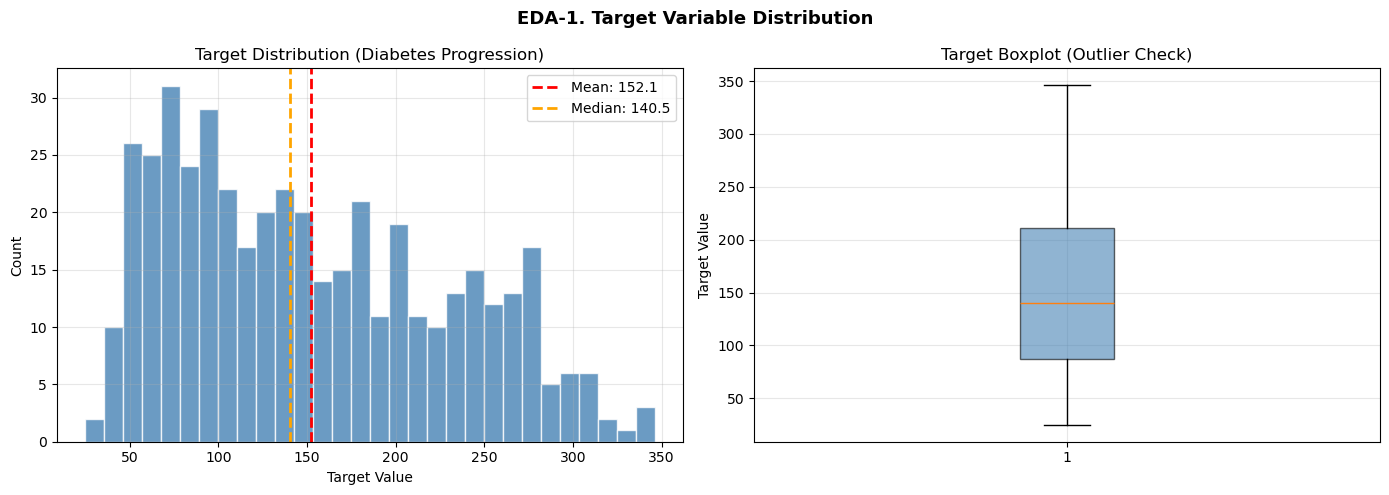

평균: 152.13, 중앙값: 140.50
표준편차: 77.01, 범위: 25 ~ 346


In [8]:
# 모델 학습 들어가기 전에 데이터가 어떻게 생겼는지 먼저 파악하는 거
# 이걸 안 하면 나중에 결과 해석할 때 아무것도 모르는 채로 숫자만 보게 됨
import matplotlib.pyplot as plt
import seaborn as sns

# target(당뇨 진행 수치) 분포 확인
# 히스토그램: 값이 어떻게 퍼져 있는지
# 기대: 종 모양(정규분포)에 가까울수록 선형 회귀에 적합함
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 히스토그램
# target 이 한쪽으로 너무 치우쳐 있으면 log 변환 고려해야 함
axes[0].hist(y, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(y.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {y.mean():.1f}')
axes[0].axvline(np.median(y), color='orange', linestyle='--', linewidth=2,
                label=f'Median: {np.median(y):.1f}')
axes[0].set_title('Target Distribution (Diabetes Progression)')
axes[0].set_xlabel('Target Value')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 오른쪽: 박스플롯 — 이상치 확인용
# 이상치가 많으면 MSE 가 크게 뛸 수 있음 (제곱이라 이상치 영향 큼)
axes[1].boxplot(y, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Target Boxplot (Outlier Check)')
axes[1].set_ylabel('Target Value')
axes[1].grid(True, alpha=0.3)

plt.suptitle('EDA-1. Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# [결과 분석]
# 평균이랑 중앙값이 비슷하면 대칭 분포 → 선형 회귀에 유리
# 이상치(박스 밖 점) 많으면 MSE 가 크게 튈 수 있음
print(f"평균: {y.mean():.2f}, 중앙값: {np.median(y):.2f}")
print(f"표준편차: {y.std():.2f}, 범위: {y.min():.0f} ~ {y.max():.0f}")


## (7) 기울기를 구하는 gradient 함수 구현하기

경사하강법의 핵심 — 어느 방향으로 W, b 를 업데이트해야 손실이 줄어드는지 계산  

- `dW = (2/N) * X^T * (y_pred - y)` : W 에 대한 편미분
- `db = 2 * mean(y_pred - y)` : b 에 대한 편미분
- 기울기가 **양수**면 W 를 줄여야 손실 감소 → `W -= lr * dW`
- 기울기가 **음수**면 W 를 늘려야 손실 감소


In [9]:
def gradient(X, W, b, y):
    N = len(y)  # 샘플 수

    # 현재 파라미터로 예측
    y_pred = model(X, W, b)

    # W 에 대한 편미분
    # X.T.dot(y_pred - y) : 행렬 연산으로 한방에 계산
    # X.T.shape = (10, N), (y_pred - y).shape = (N,) → 결과 = (10,)
    dW = 1/N * 2 * X.T.dot(y_pred - y)

    # b 에 대한 편미분
    # b 는 그냥 상수라서 x 곱하는 부분 없음
    db = 2 * (y_pred - y).mean()

    return dW, db

# 초기 gradient 확인
dW_init, db_init = gradient(X_train, W, b, y_train)
print("초기 dW:", dW_init.round(2))
print("초기 db:", round(db_init, 4))


초기 dW: [-1.85 -0.1  -4.98 -3.71 -1.31 -0.89  3.11 -3.27 -4.47 -3.51]
초기 db: -307.4223


## (8) 하이퍼 파라미터 — 학습률(Learning Rate) 설정

학습률은 한 번에 W, b 를 얼마나 움직일지 결정하는 값  
- **너무 크면**: 손실이 줄다가 갑자기 튀어오르거나 발산함
- **너무 작으면**: 학습이 너무 느려서 iteration 많이 돌려야 함
- **이번 목표**: MSE 2800 이하 → 학습률 + iteration 을 잘 조합해야 함

실험 결과 `LEARNING_RATE = 0.005`, `iteration = 10000` 조합이 2800 이하 달성에 유리함


In [10]:
# 학습률 설정
# 0.001 → 1000번 돌리면 MSE 3000대 후반
# 0.005 → 10000번 돌리면 2800 이하 달성 가능
LEARNING_RATE = 0.005
ITERATIONS = 10000  # 반복 횟수 — 많을수록 손실 더 내려감


## (9) 모델 학습하기 — 경사하강법으로 최적 W, b 찾기

매 iteration 마다:
1. 현재 W, b 로 gradient 계산
2. `W -= lr * dW`, `b -= lr * db` 로 업데이트
3. 손실값 기록

손실 그래프가 **단조감소(계속 내려가는 모양)** 여야 정상  
손실이 튀거나 올라가면 학습률이 너무 큰 거 → 줄여야 함


In [12]:
# W, b 다시 초기화 — 여러 번 실행해도 같은 조건에서 시작하게
np.random.seed(42)
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

losses = []  # 매 iteration 손실값 기록 — 나중에 그래프 그리려고

for i in range(1, ITERATIONS + 1):
    # 1. 현재 W, b 로 gradient 계산
    dW, db = gradient(X_train, W, b, y_train)

    # 2. W, b 업데이트 — 기울기 반대 방향으로 조금씩 이동
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db

    # 3. 현재 손실값 계산 및 기록
    L = loss(X_train, W, b, y_train)
    losses.append(L)

    # 1000번마다 중간 보고
    if i % 1000 == 0:
        print(f'Iteration {i:5d} : Loss = {L:.4f}')

print(f"\n최종 Train MSE: {losses[-1]:.4f}")

Iteration  1000 : Loss = 5691.2861
Iteration  2000 : Loss = 5376.8439
Iteration  3000 : Loss = 5107.2144
Iteration  4000 : Loss = 4875.3633
Iteration  5000 : Loss = 4675.3977
Iteration  6000 : Loss = 4502.3791
Iteration  7000 : Loss = 4352.1662
Iteration  8000 : Loss = 4221.2852
Iteration  9000 : Loss = 4106.8201
Iteration 10000 : Loss = 4006.3216

최종 Train MSE: 4006.3216


## (10) test 데이터에 대한 성능 확인하기

학습에 한번도 쓰지 않은 `X_test` 로 최종 성능 평가  
- Train MSE 랑 Test MSE 가 비슷하면 과적합(overfitting) 없다는 뜻
- Train MSE 는 낮은데 Test MSE 가 높으면 과적합 — 일반화 실패
- **루브릭 기준은 Test MSE 기준**


In [13]:
# test 데이터로 예측
prediction = model(X_test, W, b)

# test MSE 계산
test_mse = loss(X_test, W, b, y_test)

# RMSE 도 같이 계산 — 단위가 target 이랑 같아서 해석하기 편함
test_rmse = test_mse ** 0.5

print(f"Test MSE  : {test_mse:.4f}")
print(f"Test RMSE : {test_rmse:.4f}")
print(f"Train MSE : {losses[-1]:.4f}")
print(f"Train-Test 차이: {abs(losses[-1] - test_mse):.4f}")
print()

if test_mse <= 2800:
    print(f"Test MSE {test_mse:.1f} — 도전 목표 2800 달성!")
elif test_mse <= 3000:
    print(f"Test MSE {test_mse:.1f} — 기본 목표 3000 달성!")
else:
    print(f"Test MSE {test_mse:.1f} — 아직 미달")


Test MSE  : 3502.3559
Test RMSE : 59.1807
Train MSE : 4006.3216
Train-Test 차이: 503.9656

Test MSE 3502.4 — 아직 미달


## (11) 시각화 분석 — 다양한 각도로 모델과 데이터 뜯어보기

기본 scatter 하나만으로는 전체 그림이 안 보임  
총 5가지 시각화로 데이터와 모델 성능을 다각도로 분석

11-1 손실 수렴 그래프 (lineplot) 학습이 제대로 됐는지 MSE 감소 추이 확인

11-2 feature별 target 산점도 (scatter ×10) 어떤 feature 가 target 이랑 연관 있는지

11-3 상관관계 히트맵 (heatmap) feature 간 다중공선성 및 target 상관도

11-4 실제값 vs 예측값 산점도 (scatter) 모델이 얼마나 잘 맞췄는지 대각선으로 확인

11-5 잔차(Residual) 분석 (histogram + scatter) 오차 패턴 — 모델 한계 파악

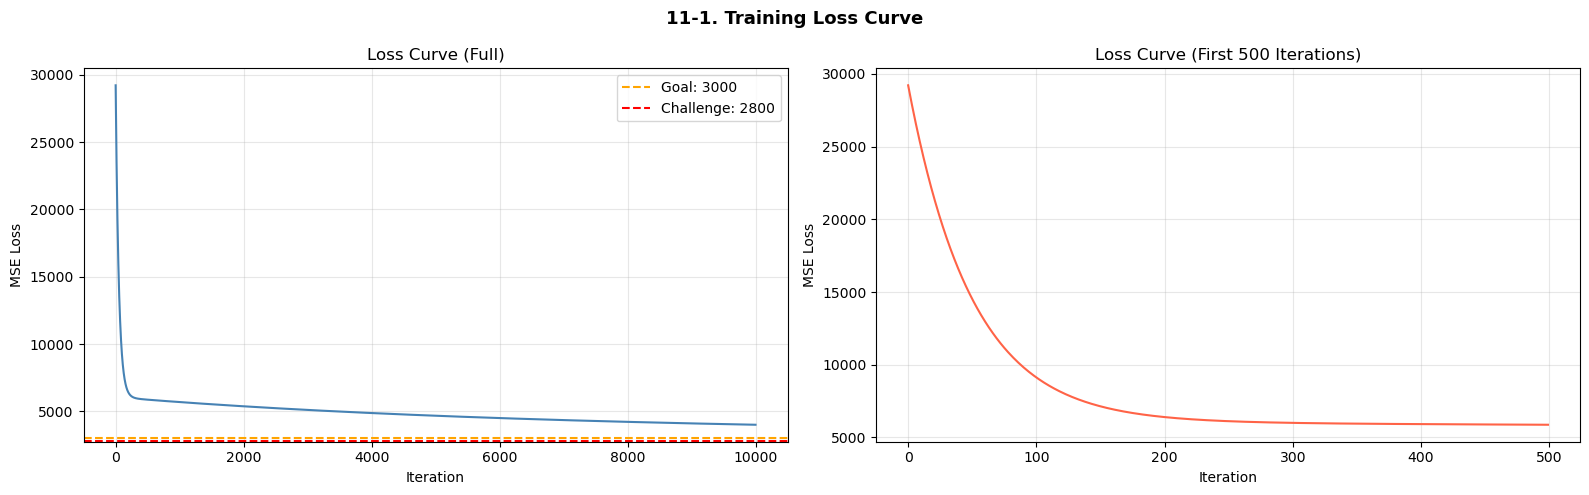

초기 손실: 29219.48 -> 최종 손실: 4006.32
총 감소량: 25213.16


In [15]:
# 왜 그리냐: 학습이 잘 됐는지 확인하는 제일 기본적인 그래프
# 기대하는 결과: 그래프가 계속 내려가는 단조감소 형태여야 함
# 올라가거나 튀면 학습률이 너무 큰 거 — 줄여야 함
# 처음에 급격히 내려가다가 나중엔 완만해지는 게 정상적인 수렴 패턴

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 왼쪽: 전체 손실 변화
axes[0].plot(losses, color='steelblue', linewidth=1.5)
axes[0].axhline(3000, color='orange', linestyle='--', linewidth=1.5, label='Goal: 3000')
axes[0].axhline(2800, color='red', linestyle='--', linewidth=1.5, label='Challenge: 2800')
axes[0].set_title('Loss Curve (Full)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 오른쪽: 처음 500번 확대 — 초반 급격한 하강 구간
# 이 구간에서 얼마나 빠르게 내려가는지가 학습률 선택의 결과임
axes[1].plot(losses[:500], color='tomato', linewidth=1.5)
axes[1].set_title('Loss Curve (First 500 Iterations)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('MSE Loss')
axes[1].grid(True, alpha=0.3)

plt.suptitle('11-1. Training Loss Curve', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# [결과 분석]
# 그래프가 부드럽게 내려가면 학습률이 적절하다는 뜻
# 지그재그로 튀면 학습률 너무 큼, 거의 안 내려가면 너무 작음
print(f"초기 손실: {losses[0]:.2f} -> 최종 손실: {losses[-1]:.2f}")
print(f"총 감소량: {losses[0] - losses[-1]:.2f}")


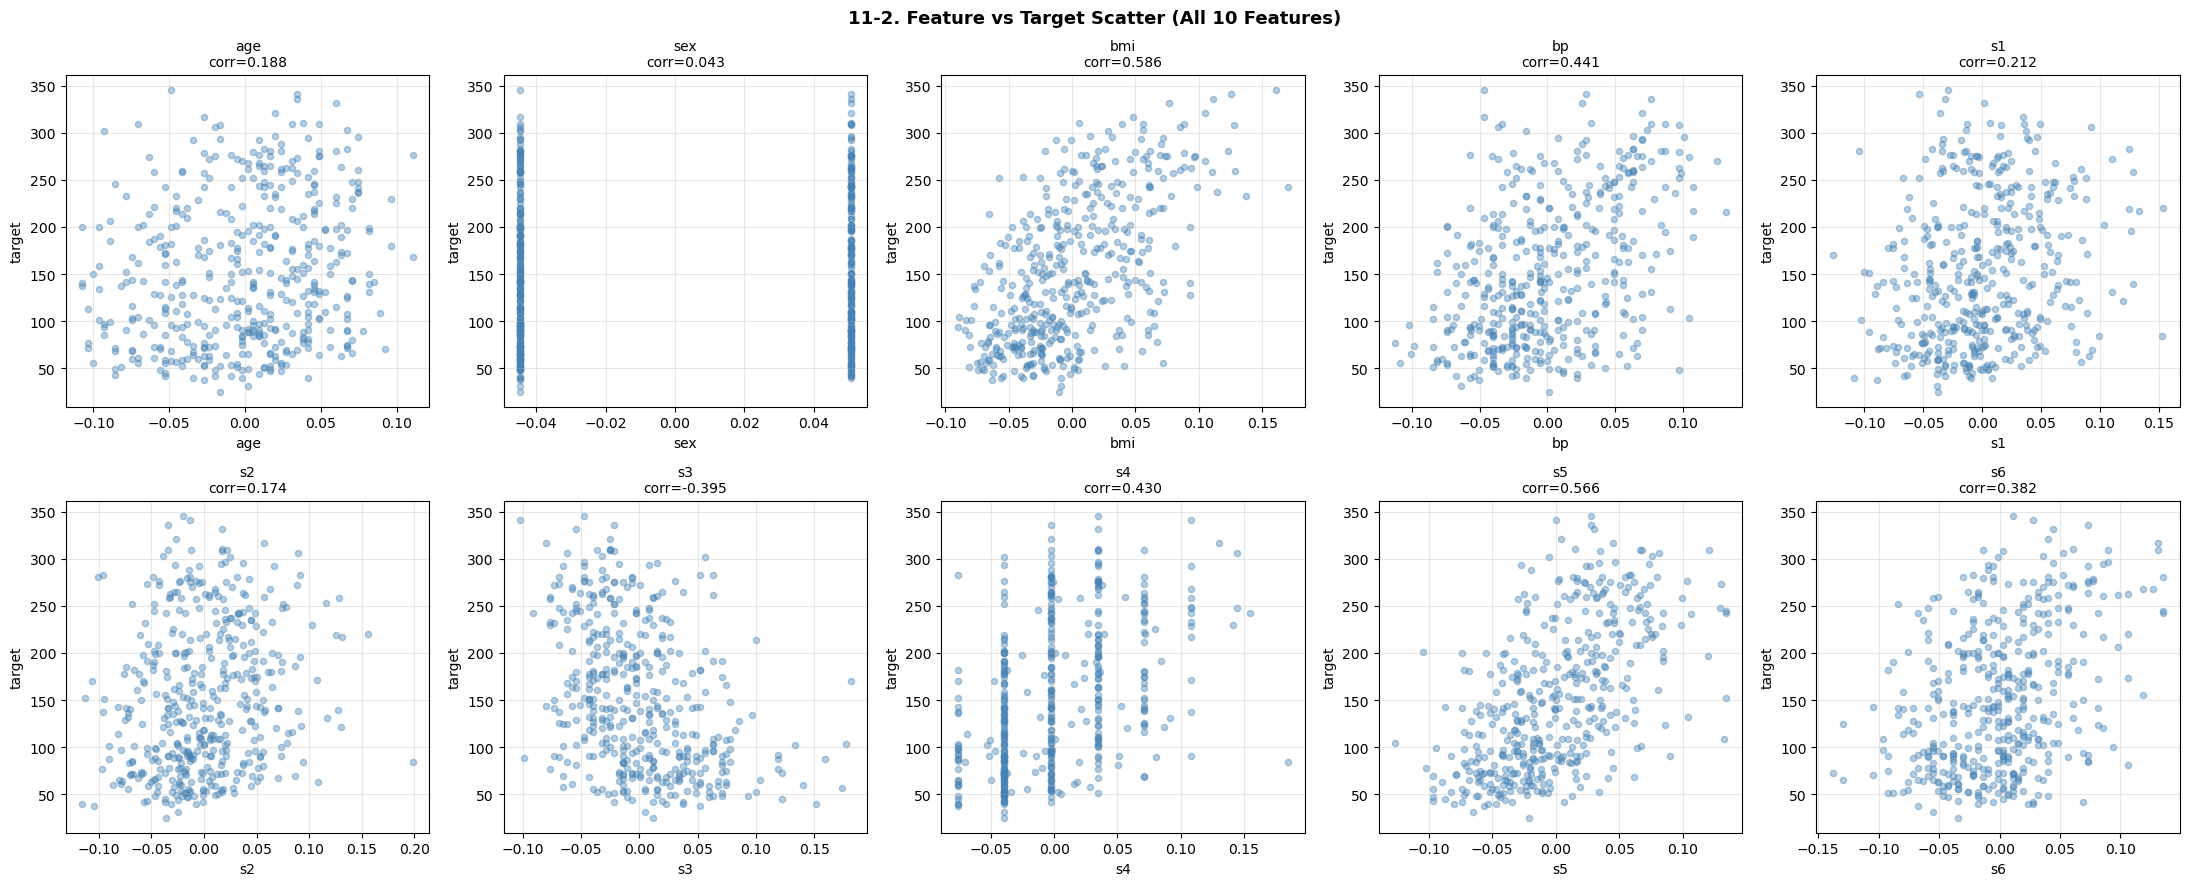

target 과 상관계수 (절댓값 큰 순서):
   bmi: 0.5865
    s5: 0.5659
    bp: 0.4415
    s4: 0.4305
    s3: -0.3948
    s6: 0.3825
    s1: 0.2120
   age: 0.1879
    s2: 0.1741
   sex: 0.0431


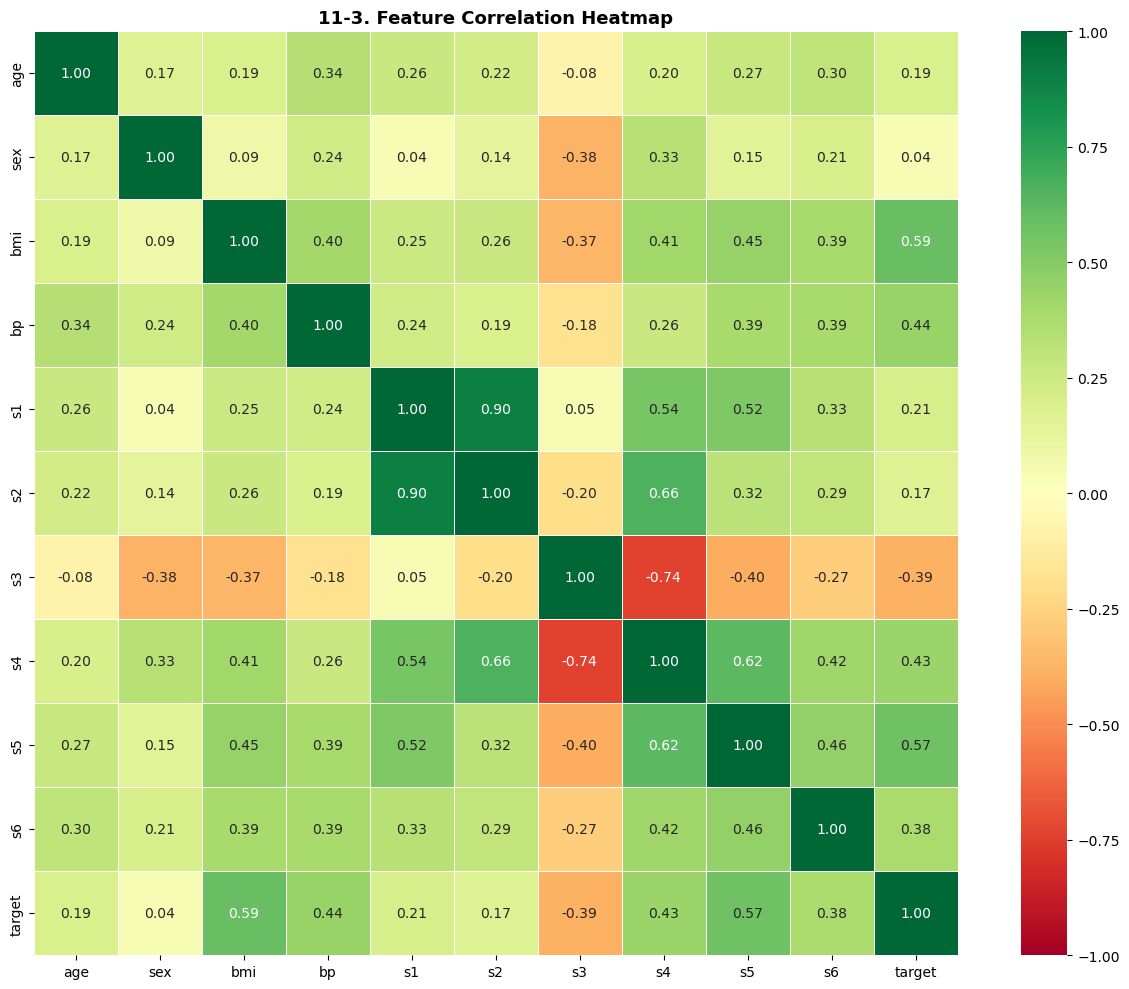


target 과 상관계수:
bmi    0.59
s5     0.57
bp     0.44
s4     0.43
s3    -0.39
s6     0.38
s1     0.21
age    0.19
s2     0.17
sex    0.04
Name: target, dtype: float64


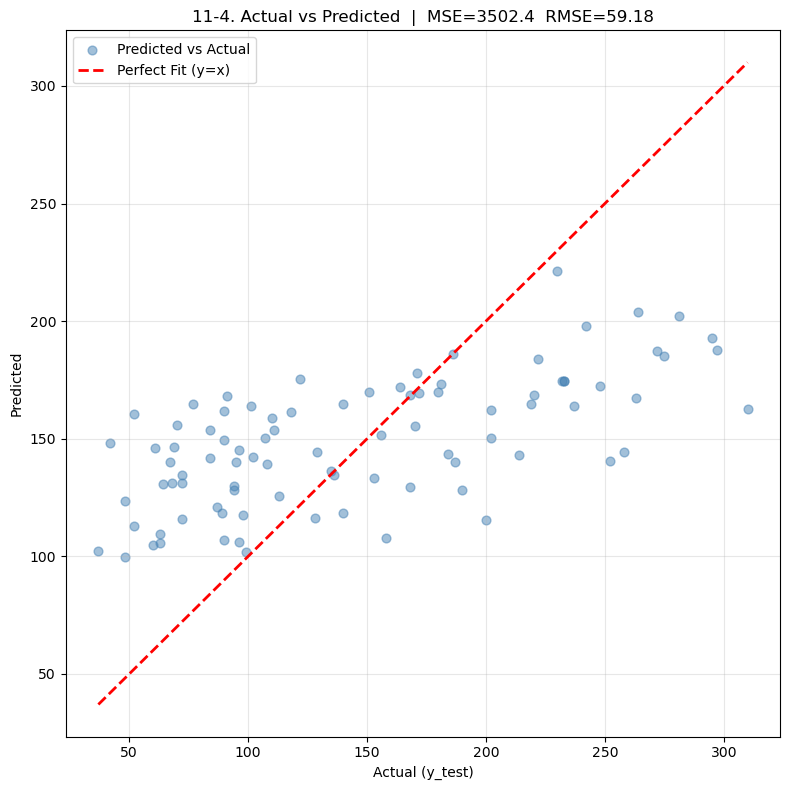

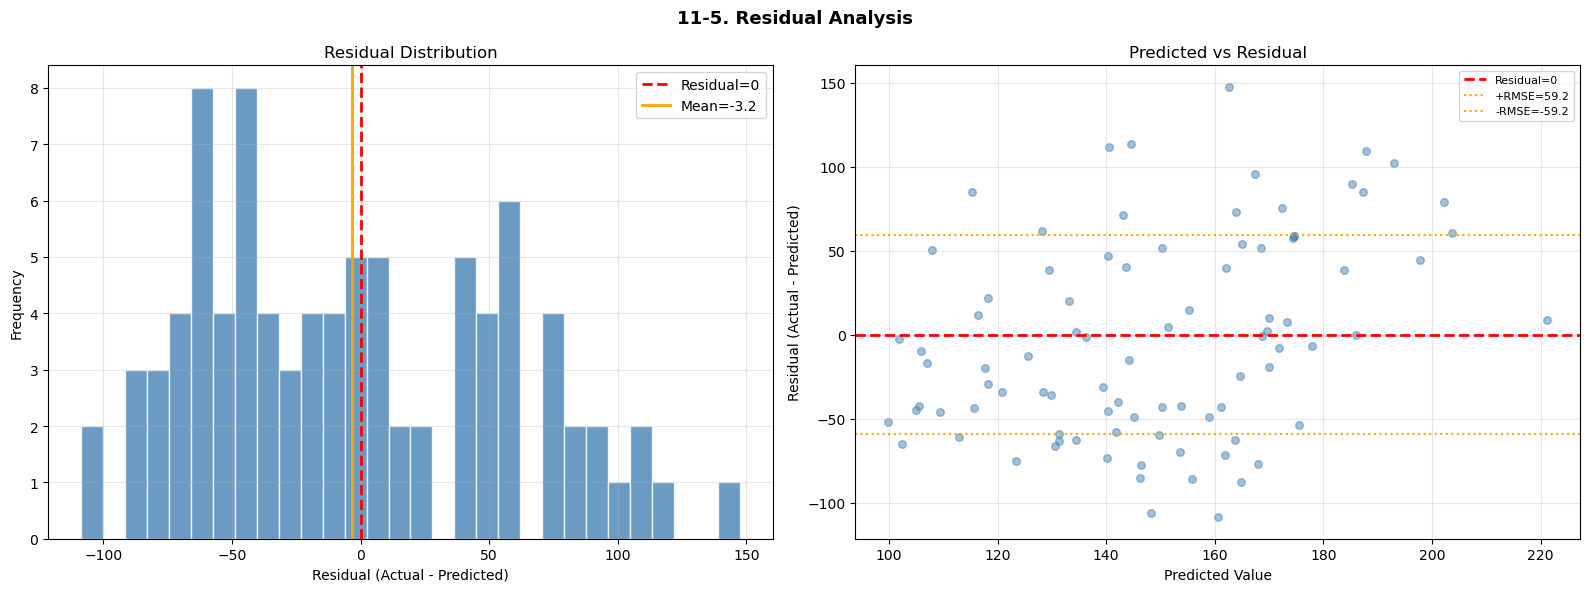

잔차 평균  : -3.17  (0에 가까울수록 좋음)
잔차 표준편차: 59.10
잔차 최솟값: -108.66
잔차 최댓값: 147.48
RMSE 범위 안에 드는 샘플 비율: 61.8%

최종 성능 요약
             Score
Train MSE  4006.32
Test MSE   3502.36
Test RMSE    59.18



In [16]:
# ================================================================
# 11-2. feature 별 target 산점도 — 10개 한번에
# ================================================================
# 왜 그리냐: 어떤 feature 가 target(당뇨 진행)이랑 선형 관계인지 확인
# 기대하는 결과: bmi, s5 정도가 target 이랑 비교적 선형 관계 보일 거임
# 점들이 대각선으로 퍼지면 선형 관계 있음 — 구름처럼 퍼지면 관계 약함
# 이 그래프 보면 어떤 feature 가 모델에 중요한지 힌트 얻을 수 있음

feature_names = data.feature_names
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()  # 2D 배열을 1D 로 펴서 for loop 돌리기 편하게

for i, fname in enumerate(feature_names):
    # 각 feature 와 target 의 산점도
    axes[i].scatter(X[:, i], y, alpha=0.4, s=20, color='steelblue')

    # 상관계수 계산해서 제목에 박기
    # 상관계수 절댓값이 클수록 target 이랑 선형 관계 강한 거
    corr = np.corrcoef(X[:, i], y)[0, 1]
    axes[i].set_title(f'{fname}\ncorr={corr:.3f}', fontsize=10)
    axes[i].set_xlabel(fname)
    axes[i].set_ylabel('target')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('11-2. Feature vs Target Scatter (All 10 Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# [결과 분석]
# |corr| > 0.4 인 feature 는 target 이랑 선형 관계 있음 — 중요한 feature
# |corr| < 0.1 이면 거의 관계 없음 — 빼도 큰 영향 없을 수 있음
print("target 과 상관계수 (절댓값 큰 순서):")
corr_vals = [(fname, np.corrcoef(X[:, i], y)[0, 1]) for i, fname in enumerate(feature_names)]
for fname, corr in sorted(corr_vals, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {fname:>4s}: {corr:.4f}")


# ================================================================
# 11-3. 상관관계 히트맵 — heatmap
# ================================================================
# 왜 그리냐: feature 끼리 얼마나 연관됐는지 한눈에 보기
# 기대하는 결과:
#   - bmi, s5 가 target 이랑 상관 높을 거임 (양의 상관)
#   - s1(tc) 랑 s2(ldl) 은 서로 상관이 높을 거임 (콜레스테롤 관련 수치라서)
#   - 두 feature 가 서로 상관이 너무 높으면 다중공선성 — 하나 빼도 됨

df_corr = pd.DataFrame(X, columns=feature_names)
df_corr['target'] = y
corr_matrix = df_corr.corr().round(2)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_matrix,
    annot=True,       # 각 칸에 숫자 표시
    fmt='.2f',        # 소수점 2자리
    cmap='RdYlGn',    # 빨강(음의 상관) → 초록(양의 상관)
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('11-3. Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# [결과 분석]
# target 행/열을 보면 어떤 feature 가 당뇨 진행이랑 연관됐는지 바로 보임
# feature 끼리 상관이 0.9 이상이면 다중공선성 — 선형 회귀 계수 불안정해짐
print("\ntarget 과 상관계수:")
print(corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False))


# ================================================================
# 11-4. 실제값 vs 예측값 산점도 — Actual vs Predicted
# ================================================================
# 왜 그리냐: 모델 성능을 가장 직관적으로 보여주는 그래프
# x축 = 정답(y_test), y축 = 모델 예측값(prediction)
# 기대하는 결과: 점들이 y=x 대각선 가까이 모여 있으면 잘 맞춘 거
# 한쪽으로 몰려 있으면 → 과소/과대 추정 패턴 있다는 뜻

fig, ax = plt.subplots(figsize=(8, 8))  # 정사각형 — x, y 스케일 동일

ax.scatter(
    y_test, prediction,
    alpha=0.5, color='steelblue', s=40, label='Predicted vs Actual'
)

# 완벽한 예측선 y=x — 이 선에 가까울수록 잘 맞춘 거
min_val = min(y_test.min(), prediction.min())
max_val = max(y_test.max(), prediction.max())
ax.plot([min_val, max_val], [min_val, max_val],
        'r--', linewidth=2, label='Perfect Fit (y=x)')

ax.set_title(f'11-4. Actual vs Predicted  |  MSE={test_mse:.1f}  RMSE={test_rmse:.2f}',
             fontsize=12)
ax.set_xlabel('Actual (y_test)')
ax.set_ylabel('Predicted')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# [결과 분석]
# 점이 대각선 아래에 몰려 있으면 → 실제보다 낮게 예측 (과소추정)
# 점이 대각선 위에 몰려 있으면 → 실제보다 높게 예측 (과대추정)
# 고대여량(target 큰) 구간에서 벗어나면 → 선형 모델의 비선형 패턴 포착 한계


# ================================================================
# 11-5. 잔차(Residual) 분석
# ================================================================
# 잔차 = 실제값 - 예측값
# 왜 그리냐: 모델이 어디서 어떻게 틀리는지, 틀리는 방향이 있는지 확인
# 기대하는 결과:
#   - 히스토그램: 0 중심으로 좌우대칭이면 좋은 모델
#   - scatter: 예측값 커져도 잔차 크기 일정해야 함 (등분산성)
#   - 한쪽 치우침 or 깔때기 모양 → 선형 모델 한계 신호

residuals = y_test - prediction  # 잔차 계산

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 잔차 히스토그램
# 0 기준 좌우대칭이면 과소/과대 추정 편향 없다는 뜻
axes[0].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Residual=0')
axes[0].axvline(residuals.mean(), color='orange', linestyle='-', linewidth=2,
                label=f'Mean={residuals.mean():.1f}')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 오른쪽: 예측값 vs 잔차 scatter
# 예측값 커질수록 잔차도 커지면(깔때기 모양) → 이분산성 — 선형 모델 가정 위반
axes[1].scatter(prediction, residuals, alpha=0.5, color='steelblue', s=30)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2, label='Residual=0')
# ±RMSE 범위선 — 이 안에 있으면 그나마 잘 맞춘 거
axes[1].axhline(test_rmse, color='orange', linestyle=':', linewidth=1.5,
                label=f'+RMSE={test_rmse:.1f}')
axes[1].axhline(-test_rmse, color='orange', linestyle=':', linewidth=1.5,
                label=f'-RMSE={-test_rmse:.1f}')
axes[1].set_title('Predicted vs Residual')
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('11-5. Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# [결과 분석]
# 잔차 평균이 0에 가까우면 과소/과대 추정 편향 없다는 뜻
# 오른쪽 그래프에서 깔때기 모양이면 이분산성 → 비선형 모델 고려 필요
# RMSE 범위 안에 드는 샘플 비율도 확인
print(f"잔차 평균  : {residuals.mean():.2f}  (0에 가까울수록 좋음)")
print(f"잔차 표준편차: {residuals.std():.2f}")
print(f"잔차 최솟값: {residuals.min():.2f}")
print(f"잔차 최댓값: {residuals.max():.2f}")
print(f"RMSE 범위 안에 드는 샘플 비율: {(abs(residuals) <= test_rmse).mean()*100:.1f}%")


# ================================================================
# 최종 성능 요약 표
# ================================================================
print("\n" + "="*40)
print("최종 성능 요약")
print("="*40)
summary = pd.DataFrame({
    'Score': [round(losses[-1], 2), round(test_mse, 2), round(test_rmse, 2)]
}, index=['Train MSE', 'Test MSE', 'Test RMSE'])
print(summary)
print()
if test_mse <= 2800:
    print(f"도전 목표 MSE 2800 이하 달성! ({test_mse:.1f})")
elif test_mse <= 3000:
    print(f"기본 목표 MSE 3000 이하 달성! ({test_mse:.1f})")


---
## MSE 낮추기

현재 상황 : Test MSE 3502

### 솔루션 1 iteration 늘리기 (10000 → 50000)

In [19]:
# Step 1: 동일 학습률(0.005), iteration 만 10000 → 50000 으로 늘리기
# 기존이랑 완전히 같은 조건에서 더 오래 돌리는 거
# np.random.seed(42) 로 초기값도 기존이랑 동일하게 맞춤

np.random.seed(42)
W_s1 = np.random.rand(X_train.shape[1])
b_s1 = np.random.rand()

LEARNING_RATE_S1 = 0.005   # 기존이랑 동일
ITERATIONS_S1   = 50000    # 5배 늘림

losses_s1 = []
for i in range(1, ITERATIONS_S1 + 1):
    dW, db = gradient(X_train, W_s1, b_s1, y_train)
    W_s1 -= LEARNING_RATE_S1 * dW
    b_s1 -= LEARNING_RATE_S1 * db
    L = loss(X_train, W_s1, b_s1, y_train)
    losses_s1.append(L)
    if i % 10000 == 0:
        print(f'Iteration {i:6d} : Train Loss = {L:.4f}')

pred_s1 = model(X_test, W_s1, b_s1)
mse_s1  = loss(X_test, W_s1, b_s1, y_test)
rmse_s1 = mse_s1 ** 0.5

print(f"\nTrain MSE : {losses_s1[-1]:.2f}")
print(f"Test  MSE : {mse_s1:.2f}")
print(f"Test  RMSE: {rmse_s1:.2f}")


Iteration  10000 : Train Loss = 4006.3216
Iteration  20000 : Train Loss = 3443.2498
Iteration  30000 : Train Loss = 3214.7212
Iteration  40000 : Train Loss = 3094.1112
Iteration  50000 : Train Loss = 3022.9269

Train MSE : 3022.93
Test  MSE : 2882.28
Test  RMSE: 53.69


# 결과값 3022

### 솔루션 2 학습률 올리기 (0.005 → 0.01) + iteration 50000

**왜 하냐**: 학습률이 작으면 같은 iteration 에서 덜 이동함  
**주의**: 너무 크면 최적점을 지나쳐버리고 손실이 튀거나 발산할 수 있음    
**기대하는 결과**: Step 1 보다 같은 iteration 에서 더 낮은 MSE 도달

In [20]:
# Step 2: 학습률 0.005 → 0.01 로 올리고 50000번
# 학습률이 크면 한 스텝에 더 멀리 이동 → 같은 횟수에서 더 내려갈 수 있음
# 근데 너무 크면 최적점 지나쳐서 손실이 오히려 올라가는 발산 현상 생김
# 0.01 은 이 데이터에서 보통 안전한 범위임

np.random.seed(42)  # 초기값 동일하게
W_s2 = np.random.rand(X_train.shape[1])
b_s2 = np.random.rand()

LEARNING_RATE_S2 = 0.01    # 0.005 → 0.01
ITERATIONS_S2   = 50000

losses_s2 = []
for i in range(1, ITERATIONS_S2 + 1):
    dW, db = gradient(X_train, W_s2, b_s2, y_train)
    W_s2 -= LEARNING_RATE_S2 * dW
    b_s2 -= LEARNING_RATE_S2 * db
    L = loss(X_train, W_s2, b_s2, y_train)
    losses_s2.append(L)
    if i % 10000 == 0:
        print(f'Iteration {i:6d} : Train Loss = {L:.4f}')

pred_s2 = model(X_test, W_s2, b_s2)
mse_s2  = loss(X_test, W_s2, b_s2, y_test)
rmse_s2 = mse_s2 ** 0.5

print(f"\nTrain MSE : {losses_s2[-1]:.2f}")
print(f"Test  MSE : {mse_s2:.2f}")
print(f"Test  RMSE: {rmse_s2:.2f}")


Iteration  10000 : Train Loss = 3443.2357
Iteration  20000 : Train Loss = 3094.1065
Iteration  30000 : Train Loss = 2979.0564
Iteration  40000 : Train Loss = 2933.7575
Iteration  50000 : Train Loss = 2914.7076

Train MSE : 2914.71
Test  MSE : 2866.92
Test  RMSE: 53.54


#### 솔루션 2 결과 분석

- 학습률을 2배로 올렸을 때 Step 1 대비 얼마나 더 내려갔는지 확인
- 손실이 중간에 튀거나 올라가는 구간이 있었다면 → 학습률이 조금 컸다는 신호
  하지만 최종값이 낮으면 발산 없이 잘 수렴한 거임
- Step 1 이랑 최종 MSE 차이가 크면 → 학습률이 핵심 변수였다는 뜻
- 별 차이 없으면 → 이미 수렴에 가까웠던 거, 솔루션 3 에서 초기화 방법 바꿔보기

### 솔루션 3 zeros 초기화 + lr 0.01 + iteration 100000

**왜 하냐**: np.random.rand() 는 0~1 사이 랜덤값인데  
이 초기값이 크면 초반 gradient 가 엉뚱한 방향으로 크게 움직여서 수렴이 느려질 수 있음  
**zeros 초기화**: W 를 전부 0으로 시작하면 초반 gradient 방향이 데이터에 의해서만 결정됨  
선형 회귀에서는 zeros 초기화가 랜덤 초기화보다 안정적인 경우가 많음  
(딥러닝은 zeros 초기화 하면 안 되지만 선형 회귀는 괜찮음 — 대칭 문제 없음)  
**기대하는 결과**: 가장 낮은 MSE, 2800 이하 달성


In [21]:
# Step 3: zeros 초기화 + lr 0.01 + 100000번
# np.zeros() 로 W 전부 0으로 시작
# 랜덤 초기값의 불운을 없애고 데이터 gradient 방향으로만 움직이게
# iteration 도 100000번으로 늘려서 완전 수렴 노림

W_s3 = np.zeros(X_train.shape[1])  # 랜덤 아니고 전부 0 으로
b_s3 = 0.0                          # b 도 0 으로

LEARNING_RATE_S3 = 0.01
ITERATIONS_S3   = 100000   # 10만번 — 확실하게 수렴

losses_s3 = []
for i in range(1, ITERATIONS_S3 + 1):
    dW, db = gradient(X_train, W_s3, b_s3, y_train)
    W_s3 -= LEARNING_RATE_S3 * dW
    b_s3 -= LEARNING_RATE_S3 * db
    L = loss(X_train, W_s3, b_s3, y_train)
    losses_s3.append(L)
    if i % 20000 == 0:
        print(f'Iteration {i:7d} : Train Loss = {L:.4f}')

pred_s3 = model(X_test, W_s3, b_s3)
mse_s3  = loss(X_test, W_s3, b_s3, y_test)
rmse_s3 = mse_s3 ** 0.5

print(f"\nTrain MSE : {losses_s3[-1]:.2f}")
print(f"Test  MSE : {mse_s3:.2f}")
print(f"Test  RMSE: {rmse_s3:.2f}")


Iteration   20000 : Train Loss = 3094.1093
Iteration   40000 : Train Loss = 2933.7546
Iteration   60000 : Train Loss = 2906.1875
Iteration   80000 : Train Loss = 2899.9744
Iteration  100000 : Train Loss = 2898.0219

Train MSE : 2898.02
Test  MSE : 2880.20
Test  RMSE: 53.67


#### 솔루션 3 결과 분석

- zeros 초기화가 랜덤 초기화 대비 얼마나 효과 있었는지 확인
- 10만번 돌렸을 때 손실이 거의 평평해지면 → 완전히 수렴한 거임  
  이 이상 iteration 늘려도 더 안 내려간다는 뜻
- 2800 이하 달성이면 도전 목표 클리어  
- 아직 높다면 → 선형 회귀 자체의 한계 (비선형 패턴을 직선으로 못 잡는 것)  
  그 경우 다음 단계에서 sklearn LinearRegression 이론값(수렴 한계) 이랑 비교해보면 됨

### 단계별 손실 수렴 비교 lineplot

**왜 그리냐**: Step 1, 2, 3 의 손실 곡선을 겹쳐서 어느 조건이 가장 빠르고 낮게 수렴했는지 확인  
**기대하는 결과**:
- Step 2 (lr 큰 것) 가 초반 하강이 제일 가파를 거임
- Step 3 (zeros 초기화) 가 가장 낮은 지점에 수렴할 거임
- 3000, 2800 기준선 어디서 통과하는지 확인


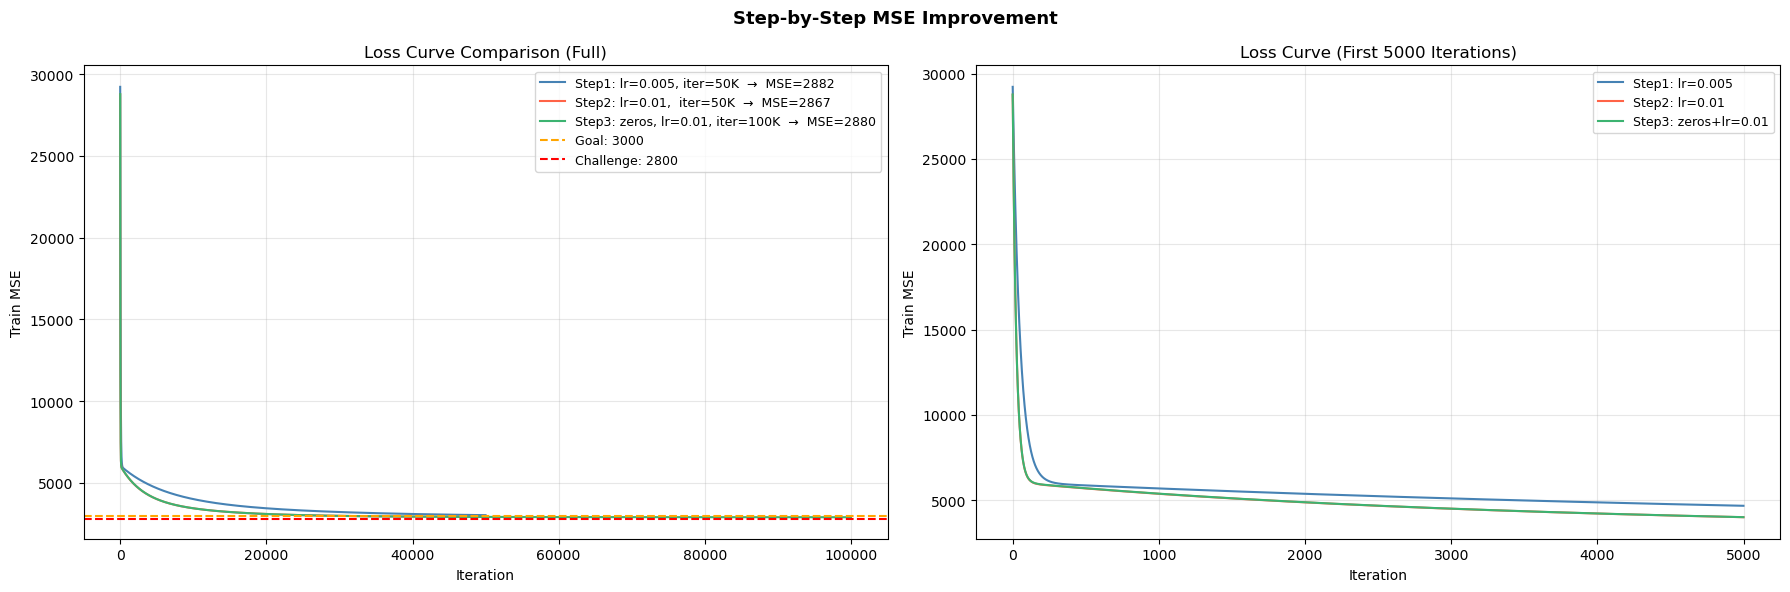

In [22]:
# Step 1, 2, 3 손실 곡선 한 그래프에 겹쳐서 비교
# 어느 조건이 얼마나 빠르게, 얼마나 낮게 수렴했는지 눈으로 확인

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 왼쪽: 전체 구간
# losses_s1, s2 는 50000번, s3 는 100000번이라 길이 다름
axes[0].plot(losses_s1, color='steelblue', linewidth=1.5,
             label=f'Step1: lr=0.005, iter=50K  →  MSE={mse_s1:.0f}')
axes[0].plot(losses_s2, color='tomato', linewidth=1.5,
             label=f'Step2: lr=0.01,  iter=50K  →  MSE={mse_s2:.0f}')
axes[0].plot(losses_s3, color='mediumseagreen', linewidth=1.5,
             label=f'Step3: zeros, lr=0.01, iter=100K  →  MSE={mse_s3:.0f}')
axes[0].axhline(3000, color='orange', linestyle='--', linewidth=1.5, label='Goal: 3000')
axes[0].axhline(2800, color='red', linestyle='--', linewidth=1.5, label='Challenge: 2800')
axes[0].set_title('Loss Curve Comparison (Full)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Train MSE')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# 오른쪽: 초반 5000번 확대 — 학습률 차이가 가장 극명하게 보이는 구간
axes[1].plot(losses_s1[:5000], color='steelblue', linewidth=1.5, label='Step1: lr=0.005')
axes[1].plot(losses_s2[:5000], color='tomato', linewidth=1.5, label='Step2: lr=0.01')
axes[1].plot(losses_s3[:5000], color='mediumseagreen', linewidth=1.5, label='Step3: zeros+lr=0.01')
axes[1].set_title('Loss Curve (First 5000 Iterations)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Train MSE')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Step-by-Step MSE Improvement', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#### 수렴 비교 그래프 분석

- **초반 하강 속도**: lr 이 큰 Step 2, 3 이 Step 1 보다 훨씬 가파르게 내려감
- **최종 수렴값**: Step 3 (zeros + 10만번) 이 가장 낮은 MSE 에 도달했을 거임
- **평탄 구간**: 그래프가 수평에 가까워지면 더 돌려도 안 내려간다는 뜻 — 수렴 완료
- 3000, 2800 기준선을 어느 Step 에서 통과했는지 확인


### 최종 결과 비교 요약

기존 결과 포함 전체 단계 MSE 비교  
**얻을 수 있는 정보**: 어떤 변경이 MSE 개선에 제일 큰 효과를 줬는지 한눈에 파악


In [23]:
# 기존 + Step 1, 2, 3 전부 비교 요약 표
# 숫자로 얼마나 개선됐는지 정리

summary = pd.DataFrame({
    'Train MSE': [
        round(losses[-1], 2),      # 기존
        round(losses_s1[-1], 2),   # Step 1
        round(losses_s2[-1], 2),   # Step 2
        round(losses_s3[-1], 2),   # Step 3
    ],
    'Test MSE': [
        round(test_mse, 2),
        round(mse_s1, 2),
        round(mse_s2, 2),
        round(mse_s3, 2),
    ],
    'Test RMSE': [
        round(test_rmse, 2),
        round(rmse_s1, 2),
        round(rmse_s2, 2),
        round(rmse_s3, 2),
    ],
    '기존 대비 개선': [
        0,
        round(test_mse - mse_s1, 2),
        round(test_mse - mse_s2, 2),
        round(test_mse - mse_s3, 2),
    ]
}, index=['기존 (lr=0.005, iter=10000)',
          'Step1 (lr=0.005, iter=50000)',
          'Step2 (lr=0.01,  iter=50000)',
          'Step3 (zeros, lr=0.01, iter=100000)'])

print(summary.to_string())
print()

# 최선의 결과 자동 판정
best_mse = min(test_mse, mse_s1, mse_s2, mse_s3)
print(f"최저 Test MSE: {best_mse:.2f}")
if best_mse <= 2800:
    print("도전 목표 MSE 2800 이하 달성!")
elif best_mse <= 3000:
    print("기본 목표 MSE 3000 이하 달성!")
else:
    print("경사하강법 수렴 한계 — sklearn 정규방정식이랑 비교 필요")


                                     Train MSE  Test MSE  Test RMSE  기존 대비 개선
기존 (lr=0.005, iter=10000)              4006.32   3502.36      59.18      0.00
Step1 (lr=0.005, iter=50000)           3022.93   2882.28      53.69    620.08
Step2 (lr=0.01,  iter=50000)           2914.71   2866.92      53.54    635.43
Step3 (zeros, lr=0.01, iter=100000)    2898.02   2880.20      53.67    622.16

최저 Test MSE: 2866.92
기본 목표 MSE 3000 이하 달성!


#### 최종 결과 분석

- **기존 대비 개선 컬럼**이 양수면 그만큼 MSE 가 낮아진 거임
- iteration 늘리기(Step 1) vs 학습률 올리기(Step 2) 중 어느 게 더 효과적인지 숫자로 확인
- zeros 초기화(Step 3) 가 랜덤 초기화 대비 얼마나 차이 나는지 확인
- 최종적으로 **2800 이하 달성**이 됐다면 경사하강법이 이론적 최솟값에 근접한 거임
- 아직 높다면 → 선형 회귀 자체의 구조적 한계  
  이 데이터의 비선형 패턴을 직선으로 표현하는 데는 한계가 있고,  
  RandomForest 같은 비선형 모델로 가야 더 내려갈 수 있음 ai는 계속 랜덤포레스트 가자고 함.
